In [1]:
from datetime import datetime
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchsummary import summary
import matplotlib.pyplot as plt

#### Loading the Data

In [2]:
training_data = datasets.FashionMNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor()
)
test_data = datasets.FashionMNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor()
)
print(training_data)
print(test_data)

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ../data
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: ../data
    Split: Test
    StandardTransform
Transform: ToTensor()


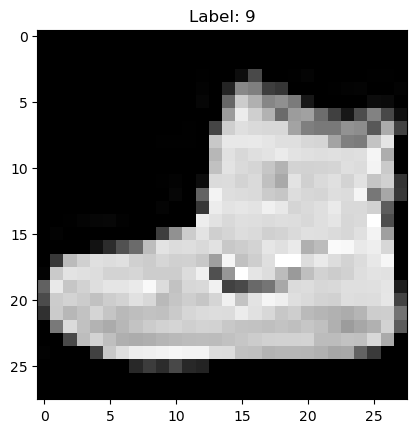

In [3]:
img, label = training_data[0]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.show()

In [4]:
import math
def plot_training(nepochs, cost_hist, cost_hist_test, acc_hist, acc_hist_test):
    plt.figure(1)
    plt.plot(torch.arange(nepochs), cost_hist, "-", label='train')
    plt.plot(torch.arange(nepochs), cost_hist_test, "r-", label='test')
    mincost = max(max(cost_hist),1.0)
    plt.xlabel("Epoch")
    plt.xlim(0,nepochs)
    plt.ylim(0,mincost)
    plt.title("Cross-Entropy Cost")
    plt.legend()
    plt.figure(2)
    plt.plot(torch.arange(nepochs), acc_hist,"-", label='train')
    plt.plot(torch.arange(nepochs), acc_hist_test,"r-", label='test')
    minacc = min(min(acc_hist),0.8)
    plt.xlabel("Epoch")
    plt.xlim(0,nepochs)
    plt.ylim(minacc,1)
    plt.legend()
    plt.title("Accuracy")

#### CNN

In [5]:
class CNN2Layer3MLPLayer(torch.nn.Module):
    
    def __init__(self, nhidden1=240, nhidden2=80, noutput=10):
        super(CNN2Layer3MLPLayer, self).__init__()
        self.layers = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1, bias=True),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, bias=True),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            torch.nn.Flatten(),
            torch.nn.Linear(14*14*32, nhidden1),
            torch.nn.ReLU(),
            torch.nn.Linear(nhidden1, nhidden2),
            torch.nn.ReLU(),
            torch.nn.Linear(nhidden2, noutput)
        ) 
    
    def forward(self, x):
        z = self.layers(x)
        return z


In [6]:
model = CNN2Layer3MLPLayer()

In [7]:
summary(model, (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
            Conv2d-3           [-1, 32, 28, 28]           9,248
              ReLU-4           [-1, 32, 28, 28]               0
         MaxPool2d-5           [-1, 32, 14, 14]               0
           Flatten-6                 [-1, 6272]               0
            Linear-7                  [-1, 240]       1,505,520
              ReLU-8                  [-1, 240]               0
            Linear-9                   [-1, 80]          19,280
             ReLU-10                   [-1, 80]               0
           Linear-11                   [-1, 10]             810
Total params: 1,535,178
Trainable params: 1,535,178
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forw

In [15]:
def norms_params(model):
    l1_norm = 0.0
    l2_norm = 0.0
    for p in model.parameters():
        l1_norm += torch.norm(p,1)
        l2_norm += torch.norm(p,2)**2
    return l1_norm, l2_norm


def norms_weights(model):
    l1_norm = 0.0
    l2_norm = 0.0
    for m in model.modules():
        if isinstance(m, (torch.nn.Linear, torch.nn.Conv2d)):
            l1_norm += torch.norm(m.weight,1)
            l2_norm += torch.norm(m.weight,2)**2
    return l1_norm, l2_norm

l1_all, l2_all = norms_params(model)
l1_weights, l2_weights = norms_weights(model)
print(l1_all, l2_all)
print(l1_weights, l2_weights)

tensor(10492.4170, grad_fn=<AddBackward0>) tensor(132.2547, grad_fn=<AddBackward0>)
tensor(10481.7666, grad_fn=<AddBackward0>) tensor(130.8874, grad_fn=<AddBackward0>)
